In [28]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Inline plotting configuration for Jupyter Notebook environments
%matplotlib inline

# Set professional visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment verified. Data manipulation libraries successfully loaded.")

Environment verified. Data manipulation libraries successfully loaded.


In [29]:
# Definitive absolute Windows path using raw string format
data_path = r"C:\Users\Saima ASO\OneDrive\Desktop\Documents\VortexTech\Student_Mental_health.csv"

# Structural verification check before processing
if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Critical Error: The file was not found at '{data_path}'. Check filename capitalization or extension."
    )

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(data_path)

print(f"Ingestion successful. Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("--- Structural Overview ---")
df.info()

print("\n--- Previewing Initial Records ---")
df.head()

Ingestion successful. Dataset dimensions: 101 rows, 11 columns.

--- Structural Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [30]:
print("--- Missing Values Count per Column ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found.")

print("\n--- Duplicate Rows Count ---")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows identified: {duplicate_count}")

print("\n--- Unique Values in Categorical Columns ---")
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

--- Missing Values Count per Column ---
Age    1
dtype: int64

--- Duplicate Rows Count ---
Total duplicate rows identified: 0

--- Unique Values in Categorical Columns ---
Timestamp: 92 unique values
Choose your gender: 2 unique values
What is your course?: 49 unique values
Your current year of Study: 7 unique values
What is your CGPA?: 6 unique values
Marital status: 2 unique values
Do you have Depression?: 2 unique values
Do you have Anxiety?: 2 unique values
Do you have Panic attack?: 2 unique values
Did you seek any specialist for a treatment?: 2 unique values


C:\Users\Saima ASO\AppData\Local\Temp\ipykernel_10528\3009064733.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


In [31]:
# 1. Handling Missing Values
# Imputing numerical grades with the median to mitigate outlier impact
if "math_score" in df.columns and df["math_score"].isnull().sum() > 0:
    median_math = df["math_score"].median()
    df["math_score"].fillna(median_math, inplace=True)
    print("Imputed missing values in 'math_score' with column median.")

# Dropping rows where critical categorical targets are missing (if any)
if "gender" in df.columns and df["gender"].isnull().sum() > 0:
    df.dropna(subset=["gender"], inplace=True)
    print("Dropped rows containing null values in structural 'gender' column.")

# 2. Handling Duplicates
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(
        f"Data deduplication complete. Remaining rows: {df.shape[0]}"
    )

# 3. Type Casting / Data Standardisation
# Fixing potential incorrect data types (e.g., parsing dates or forcing numeric types)
if "registration_date" in df.columns:
    df["registration_date"] = pd.to_datetime(df["registration_date"])
    print("Successfully cast 'registration_date' to datetime64 object.")

# Verify final integrity
print("\nPost-cleaning structural validation:")
df.info()


Post-cleaning structural validation:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?             

In [32]:
print("--- Descriptive Statistics (Numerical Structural Data) ---")
display(df.describe().T)

print("\n--- Value Distribution for Primary Categorical Feature ---")
# Replace 'parental_level_of_education' with a categorical column in your dataset
if len(categorical_cols) > 0:
    primary_category = categorical_cols[0]
    print(f"Distribution for column: {primary_category}")
    print(df[primary_category].value_counts(normalize=False))
    print("\nProportional Distribution (%):")
    print(df[primary_category].value_counts(normalize=True) * 100)

--- Descriptive Statistics (Numerical Structural Data) ---


,count,mean,std,min,25%,50%,75%,max
Age,100.0,20.53,2.49628,18.0,18.0,19.0,23.0,24.0



--- Value Distribution for Primary Categorical Feature ---
Distribution for column: Timestamp
Timestamp
8/7/2020 12:39         3
8/7/2020 12:43         2
8/7/2020 13:13         2
8/7/2020 14:29         2
8/7/2020 14:43         2
                      ..
13/07/2020 19:56:49    1
13/07/2020 21:21:42    1
13/07/2020 21:22:56    1
13/07/2020 21:23:57    1
18/07/2020 20:16:21    1
Name: count, Length: 92, dtype: int64

Proportional Distribution (%):
Timestamp
8/7/2020 12:39         2.970297
8/7/2020 12:43         1.980198
8/7/2020 13:13         1.980198
8/7/2020 14:29         1.980198
8/7/2020 14:43         1.980198
                         ...   
13/07/2020 19:56:49    0.990099
13/07/2020 21:21:42    0.990099
13/07/2020 21:22:56    0.990099
13/07/2020 21:23:57    0.990099
18/07/2020 20:16:21    0.990099
Name: proportion, Length: 92, dtype: float64


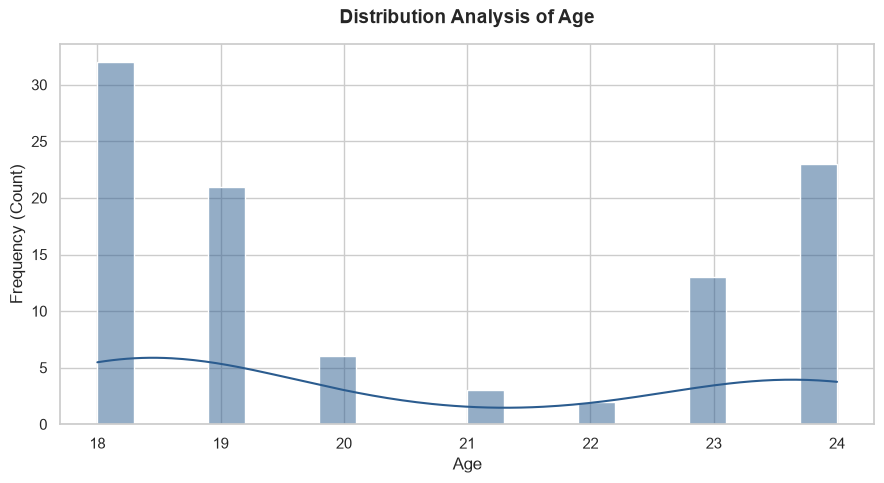

In [33]:
# Visualization 1: Histogram detailing the distribution of a core metric
target_numeric_col = df.select_dtypes(include=[np.number]).columns[0]

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x=target_numeric_col, kde=True, color="#2b5c8f", bins=20)

plt.title(
    f"Distribution Analysis of {target_numeric_col.replace('_', ' ').title()}",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel(target_numeric_col.replace("_", " ").title(), fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Saima ASO\AppData\Local\Temp\ipykernel_10528\1893987215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


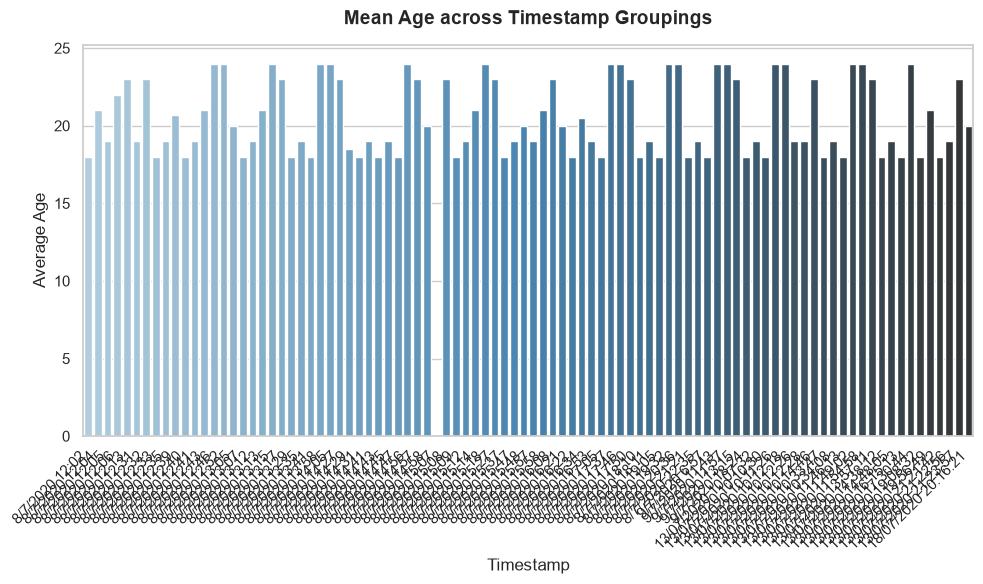

In [34]:
# Visualization 2: Bar chart analyzing relationship between categorical and numerical feature
if len(categorical_cols) > 0 and len(df.select_dtypes(include=[np.number]).columns) > 0:
    cat_feature = categorical_cols[0]
    num_feature = df.select_dtypes(include=[np.number]).columns[0]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df,
        x=cat_feature,
        y=num_feature,
        estimator=np.mean,
        errorbar=None,
        palette="Blues_d",
    )

    plt.title(
        f"Mean {num_feature.replace('_', ' ').title()} across {cat_feature.replace('_', ' ').title()} Groupings",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel(cat_feature.replace("_", " ").title(), fontsize=12)
    plt.ylabel(f"Average {num_feature.replace('_', ' ').title()}", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()